# Parallelized sweep of DTW outlier time thresholds

The two-stream DTW reference (`ref_dtw_gt_with_ends_general`) uses a time
threshold (default `300`s) to decide when the android/ios matched timestamps
have diverged enough to treat one stream as an outlier. This notebook sweeps
that threshold across a range of values and builds every (timeline, section,
threshold) reference in parallel using the same joblib loky process pool used
by `trajectory_evaluation_spatio_temporal_all.ipynb`, then aggregates the
resulting stats so the threshold can be tuned.

In [1]:
# for reading and validating data
import emeval.input.spec_details as eisd
import emeval.input.phone_view as eipv
import emeval.input.eval_view as eiev

# Metrics helpers
import emeval.metrics.dist_calculations as emd
import emeval.metrics.reference_trajectory as emr

# For computation
import numpy as np
import pandas as pd
import geopandas as gpd
import shapely as shp
import matplotlib.pyplot as plt
import arrow
import os
import copy
import pickle
from joblib import Parallel, delayed
import importlib
importlib.reload(emr)

/home/kgovil/miniconda-23.1.0/envs/emissioneval/lib/python3.11/site-packages/pyproj/crs/crs.py:141: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)
/home/kgovil/miniconda-23.1.0/envs/emissioneval/lib/python3.11/site-packages/pyproj/crs/crs.py:141: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)


<module 'emeval.metrics.reference_trajectory' from '/kfs2/projects/teta/kgovil/mobilitynet-analysis-scripts/emeval/metrics/reference_trajectory.py'>

In [2]:
DATASTORE_LOC = "bin/data"
AUTHOR_EMAIL = "shankari@eecs.berkeley.edu"
sd_la = eisd.FileSpecDetails(DATASTORE_LOC, AUTHOR_EMAIL, "unimodal_trip_car_bike_mtv_la")
sd_sj = eisd.FileSpecDetails(DATASTORE_LOC, AUTHOR_EMAIL, "car_scooter_brex_san_jose")
sd_ucb = eisd.FileSpecDetails(DATASTORE_LOC, AUTHOR_EMAIL, "train_bus_ebike_mtv_ucb")

pv_la = eipv.PhoneView(sd_la)
pv_sj = eipv.PhoneView(sd_sj)
pv_ucb = eipv.PhoneView(sd_ucb)
pvs = [pv_la, pv_sj, pv_ucb]

After iterating over 1 entries, entry found
Found spec = Round trip car and bike trip in the South Bay
Evaluation ran from 2019-07-20T00:00:00-07:00 -> 2020-04-29T17:00:00-07:00
After iterating over 1 entries, entry found
Found spec = Multi-modal car scooter BREX trip to San Jose
Evaluation ran from 2019-07-20T00:00:00-07:00 -> 2020-04-29T17:00:00-07:00
After iterating over 1 entries, entry found
Found spec = Multimodal multi-train, multi-bus, ebike trip to UC Berkeley
Evaluation ran from 2019-07-16T00:00:00-07:00 -> 2020-04-30T00:00:00-07:00
-------------------- About to read transitions from server --------------------
Reading data for android phones
Loading transitions for phone ucb-sdb-android-1
Loading transitions for phone ucb-sdb-android-2
Loading transitions for phone ucb-sdb-android-3
Loading transitions for phone ucb-sdb-android-4
Reading data for ios phones
Loading transitions for phone ucb-sdb-ios-1
Loading transitions for phone ucb-sdb-ios-2
Loading transitions for phone u

Loading transitions for phone ucb-sdb-ios-4
-------------------- About to fill calibration ranges --------------------
Processing data for android phones
Processing transitions for phone ucb-sdb-android-1
Filtered 86 total -> 0 calibration transitions 
Processing transitions for phone ucb-sdb-android-2
Filtered 86 total -> 0 calibration transitions 
Processing transitions for phone ucb-sdb-android-3
Filtered 86 total -> 0 calibration transitions 
Processing transitions for phone ucb-sdb-android-4
Filtered 86 total -> 0 calibration transitions 
Processing data for ios phones
Processing transitions for phone ucb-sdb-ios-1
Filtered 1114 total -> 0 calibration transitions 
Processing transitions for phone ucb-sdb-ios-2
Filtered 88 total -> 0 calibration transitions 
Processing transitions for phone ucb-sdb-ios-3
Filtered 86 total -> 0 calibration transitions 
Processing transitions for phone ucb-sdb-ios-4
Filtered 86 total -> 0 calibration transitions 
Processing data for android phones
--

Processing data for ios phones


-------------------- About to fill in location information --------------------
Processing data for android phones
Processing data for ios phones
Processing data for android phones


Processing data for ios phones


...

Filling label ucb-sdb-ios-1 for OS ios


Filling label ucb-sdb-ios-2 for OS ios


Filling label ucb-sdb-ios-3 for OS ios


Filling label ucb-sdb-ios-4 for OS ios


-------------------- Done populating information from server --------------------


In [3]:
def get_reference_trajectory_input_tree(pv):
    ref_tree = {}

    for phone_os, phone_map in pv.map().items():
        for phone_label, phone_detail_map in phone_map.items():
            for (r_idx, r) in enumerate(phone_detail_map["evaluation_ranges"]):
                if r["eval_role_base"] != "accuracy_control":
                    continue
                for (tr_idx, tr) in enumerate(r["evaluation_trip_ranges"]):
                    for (sr_idx, sr) in enumerate(tr["evaluation_section_ranges"]):
                        section_gt_leg = pv.spec_details.get_ground_truth_for_leg(tr["trip_id_base"], sr["trip_id_base"], sr["start_ts"], sr["end_ts"])
                        section_gt_shapes = gpd.GeoSeries(eisd.SpecDetails.get_shapes_for_leg(section_gt_leg))
                        if len(section_gt_shapes) == 1:
                            print("No ground truth route for %s %s, must be polygon, skipping..." % (tr["trip_id_base"], sr["trip_id_base"]))
                            assert section_gt_leg["type"] != "TRAVEL", "For %s, %s, %s, %s, %s found type %s" % (phone_os, phone_label, r_idx, tr_idx, sr_idx, section_gt_leg["type"])
                            continue
                        if len(sr['location_df']) == 0:
                            print("No sensed locations found, role = %s skipping..." % (r["eval_role_base"]))
                            continue

                        print("Processing travel leg %s, %s, %s, %s, %s" %
                              (phone_os, phone_label, r["eval_role_base"], tr["trip_id_base"], sr["trip_id_base"]))
                        sec_name = tr["trip_id_base"] + "/" + sr["trip_id_base"] + "_" + str(r_idx)
                        if sec_name not in ref_tree:
                            ref_tree[sec_name] = {
                                "trip_id": tr["trip_id_base"],
                                "section_id": sr["trip_id_base"],
                                "run": r_idx,
                                "ground_truth": {
                                    "leg": section_gt_leg
                                }
                            }

                        assert sec_name in ref_tree
                        e = ref_tree[sec_name]
                        section_measured_points = sr["location_df"]
                        if "temporal_control" not in e:
                            e["temporal_control"] = {}
                            e["start_ts"] = sr["start_ts"]
                            e["end_ts"] = sr["end_ts"]
                        e["temporal_control"][phone_os] = sr
    return ref_tree

## Build the input trees once, then sweep in two phases

The ground-truth / location loading is expensive, so we do it serially once per
timeline and pre-serialize each section's base entry. The sweep itself runs in
two phases:

1. **Match once** — `dtw_match_segment` runs the DTW (the expensive,
   threshold-independent part) one time per segment, in parallel.
2. **Process many** — `dtw_process_match` reprocesses each cached match for
   every threshold (the cheap, threshold-dependent part).

So the whole sweep costs a single DTW pass per segment instead of one per
`(segment, threshold)` pair.


In [4]:
# Python 3.11 still has the GIL, so a ThreadPoolExecutor gains nothing for this
# CPU-bound work. Use joblib's process-based parallelism (loky backend) so the
# builders actually run concurrently across cores.
N_JOBS = 100

# Time thresholds (seconds) to sweep. 300 is the historical default.
TIME_THRESHOLDS = [10, 30, 60, 120, 180, 240]

In [5]:
# Build the (threshold-independent) input trees once per timeline.
input_trees = {}      # timeline_id -> {sec_name: base_entry}
timeline_tz = {}      # timeline_id -> tz
for pv in pvs:
    input_trees[pv.spec_details.CURR_SPEC_ID] = get_reference_trajectory_input_tree(pv)
    timeline_tz[pv.spec_details.CURR_SPEC_ID] = pv.spec_details.eval_tz

# Pre-serialize every section's base_entry exactly once. base_entry holds the
# raw android/ios location dataframes and is expensive to pickle, so doing it
# here means the same bytes are reused for every threshold task that operates on
# that section instead of joblib re-pickling the live object once per task.
serialized_entries = {}   # timeline_id -> {sec_name: pickled base_entry bytes}
for timeline, tree_in in input_trees.items():
    serialized_entries[timeline] = {
        sec_name: pickle.dumps(base_entry, protocol=pickle.HIGHEST_PROTOCOL)
        for sec_name, base_entry in tree_in.items()
    }

No ground truth route for suburb_city_driving_weekend walk_start, must be polygon, skipping...
Processing travel leg android, ucb-sdb-android-1, accuracy_control, suburb_city_driving_weekend, suburb_city_driving_weekend
No ground truth route for suburb_city_driving_weekend walk_end, must be polygon, skipping...
No ground truth route for suburb_bicycling walk_start, must be polygon, skipping...
Processing travel leg android, ucb-sdb-android-1, accuracy_control, suburb_bicycling, suburb_bicycling
No ground truth route for suburb_bicycling walk_end, must be polygon, skipping...
No ground truth route for suburb_city_driving_weekend walk_start, must be polygon, skipping...
Processing travel leg android, ucb-sdb-android-1, accuracy_control, suburb_city_driving_weekend, suburb_city_driving_weekend
No ground truth route for suburb_city_driving_weekend walk_end, must be polygon, skipping...
No ground truth route for suburb_bicycling walk_start, must be polygon, skipping...
Processing travel leg

Processing travel leg ios, ucb-sdb-ios-1, accuracy_control, mtv_to_berkeley_sf_bart, city_bus_short
No ground truth route for mtv_to_berkeley_sf_bart walk_end, must be polygon, skipping...
Processing travel leg ios, ucb-sdb-ios-1, accuracy_control, walk_urban_university, walk_urban_university
Processing travel leg ios, ucb-sdb-ios-1, accuracy_control, berkeley_to_mtv_SF_express_bus, walk to the bikeshare location
Processing travel leg ios, ucb-sdb-ios-1, accuracy_control, berkeley_to_mtv_SF_express_bus, ebike_bikeshare_urban_long
No ground truth route for berkeley_to_mtv_SF_express_bus tt_ebike_bikeshare_urban_long_express_bus, must be polygon, skipping...
No ground truth route for berkeley_to_mtv_SF_express_bus wait_for_express_bus, must be polygon, skipping...
Processing travel leg ios, ucb-sdb-ios-1, accuracy_control, berkeley_to_mtv_SF_express_bus, express_bus
Processing travel leg ios, ucb-sdb-ios-1, accuracy_control, berkeley_to_mtv_SF_express_bus, walk_downtown_urban_canyon
No g

In [6]:
# --- Split ref_dtw_gt_with_ends_general into two parts -----------------------
# Part 1 (dtw_match_segment) does the EXPENSIVE, threshold-INDEPENDENT work:
#   interpolation + DTW matching of the ground truth against each device stream,
#   and grouping the matches into first/second-pass indexes.
# Part 2 (dtw_process_match) does the CHEAP, threshold-DEPENDENT work: the
#   outlier removal driven by `time_threshold`, the second-pass interpolation,
#   and building the reference GeoDataFrame.
# Splitting them lets us run the DTW matching ONCE per segment and then reprocess
# that cached match for many thresholds without repeating the DTW.
import emeval.metrics.DTW as dtw


def dtw_match_segment(e, tz="UTC", points_per_second=1, interp=2):
    """Part 1: threshold-independent DTW matching. Mirrors the head of
    emr.ref_dtw_gt_with_ends_general and returns everything dtw_process_match
    needs as a plain (picklable) dict."""
    emr.fill_gt_linestring(e)
    a_pts = emd.to_geo_df(e["temporal_control"]["android"]["location_df"])
    i_pts = emd.to_geo_df(e["temporal_control"]["ios"]["location_df"])
    if interp >= 1:
        new_a_pts = emr.get_int_aligned_trajectory(a_pts, tz, True, True)
        new_i_pts = emr.get_int_aligned_trajectory(i_pts, tz, True, True)
    else:
        new_a_pts = a_pts
        new_i_pts = i_pts
    a_pts_seq = new_a_pts["geometry"].to_list()
    i_pts_seq = new_i_pts["geometry"].to_list()

    start_ts = min(new_a_pts["ts"].iloc[0], new_i_pts["ts"].iloc[0])
    end_ts = max(new_a_pts["ts"].iloc[-1], new_i_pts["ts"].iloc[-1])

    # Get points at 1 second intervals along the ground truth linestring
    if interp == 0 or interp == 2:
        gt_pts = emr.interpolate_points_along_linestring(
            e["ground_truth"]["linestring"], time_interval=(end_ts - start_ts),
            points_per_second=points_per_second)
    else:
        gt_pts = [shp.geometry.Point(coord) for coord in list(e["ground_truth"]["linestring"].coords)]

    d_a = dtw.Dtw(gt_pts, a_pts_seq, dtw.calDistance)
    d_a.calculate()
    mapping_a = d_a.get_path()

    d_i = dtw.Dtw(gt_pts, i_pts_seq, dtw.calDistance)
    d_i.calculate()
    mapping_i = d_i.get_path()

    groups_a = []
    a_idx = len(mapping_a) - 1
    groups_i = []
    i_idx = len(mapping_i) - 1
    match_streak = 0
    firstpass_idxes = []
    secondpass_idxes = []
    for idx in range(len(gt_pts)):
        group_a = []
        group_i = []
        while a_idx >= 0 and mapping_a[a_idx][0] == idx:
            group_a.append(mapping_a[a_idx][1])
            a_idx -= 1
        while i_idx >= 0 and mapping_i[i_idx][0] == idx:
            group_i.append(mapping_i[i_idx][1])
            i_idx -= 1
        if len(groups_a) > 0 and groups_a[-1] == group_a and groups_i[-1] == group_i:
            if match_streak == 0:
                secondpass_idxes.append([idx])
            else:
                secondpass_idxes[-1].append(idx)
            match_streak += 1
        else:
            firstpass_idxes.append(idx)
            match_streak = 0
        groups_a.append(group_a)
        groups_i.append(group_i)

    return {
        "gt_pts": gt_pts,
        "new_a_pts": new_a_pts,
        "new_i_pts": new_i_pts,
        "a_pts_seq": a_pts_seq,
        "i_pts_seq": i_pts_seq,
        "groups_a": groups_a,
        "groups_i": groups_i,
        "firstpass_idxes": firstpass_idxes,
        "secondpass_idxes": secondpass_idxes,
    }


def dtw_process_match(match, tz="UTC", time_threshold=300):
    """Part 2: threshold-dependent processing. Mirrors the tail of
    emr.ref_dtw_gt_with_ends_general, consuming the dict from
    dtw_match_segment. Only `time_threshold` changes between sweep runs."""
    gt_pts = match["gt_pts"]
    new_a_pts = match["new_a_pts"]
    new_i_pts = match["new_i_pts"]
    a_pts_seq = match["a_pts_seq"]
    i_pts_seq = match["i_pts_seq"]
    groups_a = match["groups_a"]
    groups_i = match["groups_i"]
    firstpass_idxes = match["firstpass_idxes"]
    secondpass_idxes = match["secondpass_idxes"]

    def get_centriod_and_ts(idx, timeseries_id):
        if timeseries_id == 0:
            centroid_a, ts_a = get_centriod_and_ts(idx, 1)
            centroid_i, ts_i = get_centriod_and_ts(idx, 2)
            return shp.geometry.MultiPoint([centroid_a, centroid_i]).centroid, (ts_a + ts_i) / 2
        if timeseries_id == 1:
            groups = groups_a
            pts = new_a_pts
        elif timeseries_id == 2:
            groups = groups_i
            pts = new_i_pts

        unique_elements = set()
        for pt in groups[idx]:
            unique_elements.add(pt)
        df = pts.iloc[list(unique_elements)]
        matched_points = df["geometry"].to_list()
        matched_ts = df["ts"].to_list()
        matched_ts_mean = np.mean(matched_ts)
        matched_points_centroid = shp.geometry.MultiPoint(matched_points).centroid
        return matched_points_centroid, matched_ts_mean

    # First pass
    points = []
    timestamps = []
    timeseries_ids = []
    offset = 0
    timeseries_id = 0  # 0 for dtw, 1 for android, 2 for ios
    for idx in firstpass_idxes:
        matched_points_centroid_a, matched_ts_mean_a = get_centriod_and_ts(idx, 1)
        matched_points_centroid_i, matched_ts_mean_i = get_centriod_and_ts(idx, 2)

        # Outlier removal driven by the swept threshold
        if abs(matched_ts_mean_a - matched_ts_mean_i) > time_threshold:
            if dtw.calDistance(gt_pts[idx], matched_points_centroid_a) > dtw.calDistance(gt_pts[idx], matched_points_centroid_i):
                if timeseries_id != 2:
                    burn, prev_new = get_centriod_and_ts(idx - 1, 2)
                    burn, prev_old = get_centriod_and_ts(idx - 1, timeseries_id)
                    offset += prev_old - prev_new
                    timeseries_id = 2
                points.append(gt_pts[idx])
                timestamps.append(matched_ts_mean_i + offset)
                timeseries_ids.append(2)
                continue
            else:
                if timeseries_id != 1:
                    burn, prev_new = get_centriod_and_ts(idx - 1, 1)
                    burn, prev_old = get_centriod_and_ts(idx - 1, timeseries_id)
                    offset += prev_old - prev_new
                    timeseries_id = 1
                points.append(gt_pts[idx])
                timestamps.append(matched_ts_mean_a + offset)
                timeseries_ids.append(1)
                continue

        # Average remaining points
        if timeseries_id != 0:
            burn, prev_new = get_centriod_and_ts(idx - 1, 0)
            burn, prev_old = get_centriod_and_ts(idx - 1, timeseries_id)
            offset += prev_old - prev_new
            timeseries_id = 0
        ts = (matched_ts_mean_a + matched_ts_mean_i) / 2
        points.append(gt_pts[idx])
        timestamps.append(ts + offset)
        timeseries_ids.append(0)

    # Second pass
    for idx_list in secondpass_idxes:
        first_idx = idx_list[0]
        timeseries_id = timeseries_ids[first_idx - 1]
        if first_idx >= len(timestamps):
            first_stamp = timestamps[-2]
            last_stamp = timestamps[-1]
            step = (last_stamp - first_stamp) / (len(idx_list) + 1)
            timestamps[-1] = first_stamp + step
            first_stamp += step
            last_stamp += step
        else:
            first_stamp = timestamps[first_idx - 1]
            last_stamp = timestamps[first_idx]
        step = (last_stamp - first_stamp) / (len(idx_list) + 1)
        for n in range(len(idx_list)):
            points.insert(idx_list[n], gt_pts[idx_list[n]])
            timestamps.insert(idx_list[n], first_stamp + ((n + 1) * step))
            timeseries_ids.insert(idx_list[n], timeseries_id)

    if len(points) == 0:
        return gpd.GeoDataFrame()

    gpdf = gpd.GeoDataFrame(data={'ts': timestamps}, geometry=points)
    emr.speed_acceleration_jerk(gpdf)

    matching = []
    secondpass_set = set()
    for idx_list in secondpass_idxes:
        secondpass_set.update(idx_list)

    for m in range(len(gt_pts)):
        match_row = [gt_pts[m]]
        if m not in secondpass_set:
            if timeseries_ids[m] == 1 or timeseries_ids[m] == 0:
                match_row += [a_pts_seq[a_pts] for a_pts in groups_a[m]]
            if timeseries_ids[m] == 2 or timeseries_ids[m] == 0:
                match_row += [i_pts_seq[i_pts] for i_pts in groups_i[m]]
        matching.append(match_row)
    gpdf['matching'] = matching
    gpdf['timeseries_id'] = timeseries_ids
    gpdf['longitude'] = gpdf.geometry.x
    gpdf['latitude'] = gpdf.geometry.y
    gpdf["fmt_time"] = gpdf.ts.apply(lambda ts: arrow.get(ts).to(tz))
    assert len(gpdf[gpdf.geometry.isnull()]) == 0, "Found %d null entries out of %d total" % (len(gpdf.geometry.isnull()), len(gpdf))
    return gpdf


def stats_for_ref(ref_df, e):
    """The same per-reference stats that emr.ref_and_stats computes."""
    emr.speed_acceleration_jerk(ref_df)
    stats = {
        "coverage_density": emr.coverage_density(ref_df, e),
        "coverage_time": emr.coverage_time(ref_df, e),
        "coverage_max_gap": emr.coverage_max_gap(ref_df, e),
        "max_jerk": emr.max_jerk(ref_df, e),
        "max_acceleration": emr.max_acceleration(ref_df, e),
        "max_speed": emr.max_speed(ref_df, e),
        "median_jerk": emr.median_jerk(ref_df, e),
        "mean_median_jerk_ratio": emr.mean_median_jerk_ratio(ref_df, e),
    }
    try:
        stats["gt_error"] = emd.dist_using_projection_adjusted(ref_df, e["ground_truth"]["linestring"])
    except Exception as exp_gt:
        print("Found exception %s while computing gt_error" % exp_gt)
        stats["gt_error"] = np.nan
    return stats


In [7]:
# Phase 1: run the DTW matching ONCE per segment (the expensive part), in
# parallel across the process pool. Each worker runs the DTW, saves the matching
# results, and returns the path to the saved file so phase 2 can reprocess it.
def ref_fn(variant, timeline, sec_name, include_ends=True):
    prefix = "with_ends" if include_ends else "no_ends"
    return "bin/ref_trees/" + variant + "/" + timeline + "/" + prefix + "/" + sec_name + "/pre_process"

def build_match_file(timeline, sec_name, base_entry_bytes, tz):
    e = pickle.loads(base_entry_bytes)
    try:
        match = dtw_match_segment(e, tz=tz)
        fn = ref_fn("dtw_sweep", timeline, sec_name, include_ends=True)
        os.makedirs(os.path.dirname(fn), exist_ok=True)
        with open(fn, "wb") as f:
            pickle.dump(match, f, protocol=pickle.HIGHEST_PROTOCOL)
    except Exception as exp:
        print("match for %s/%s failed: %s" % (timeline, sec_name, exp))
        return (timeline, sec_name, None)
    return (timeline, sec_name, fn)

match_tasks = []
for timeline, tree_in in input_trees.items():
    for sec_name in tree_in:
        match_tasks.append((timeline, sec_name,
                            serialized_entries[timeline][sec_name], timeline_tz[timeline]))

print("Phase 1: DTW-matching %d segments on %d processes" % (len(match_tasks), N_JOBS))
match_results = Parallel(n_jobs=N_JOBS, verbose=10)(
    delayed(build_match_file)(*t) for t in match_tasks)
match_files = {(tl, sn): fn for (tl, sn, fn) in match_results}
print("Matched %d of %d segments" %
      (sum(1 for v in match_files.values() if v is not None), len(match_tasks)))


Phase 1: DTW-matching 196 segments on 100 processes


[Parallel(n_jobs=100)]: Using backend LokyBackend with 100 concurrent workers.


/home/kgovil/miniconda-23.1.0/envs/emissioneval/lib/python3.11/site-packages/pyproj/crs/crs.py:141: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)
/home/kgovil/miniconda-23.1.0/envs/emissioneval/lib/python3.11/site-packages/pyproj/crs/crs.py:141: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)


/home/kgovil/miniconda-23.1.0/envs/emissioneval/lib/python3.11/site-packages/pyproj/crs/crs.py:141: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)
/home/kgovil/miniconda-23.1.0/envs/emissioneval/lib/python3.11/site-packages/pyproj/crs/crs.py:141: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)
/home/kgovil/miniconda-23.1.0/envs/emissioneval/lib/python3.11/site-packages/pyproj/crs/crs.py:141: FutureWarning: '+init=<authority>:<code>' syntax is 

/home/kgovil/miniconda-23.1.0/envs/emissioneval/lib/python3.11/site-packages/pyproj/crs/crs.py:141: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)
/home/kgovil/miniconda-23.1.0/envs/emissioneval/lib/python3.11/site-packages/pyproj/crs/crs.py:141: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)
/home/kgovil/miniconda-23.1.0/envs/emissioneval/lib/python3.11/site-packages/pyproj/crs/crs.py:141: FutureWarning: '+init=<authority>:<code>' syntax is 

...

After filtering against polygons 2, 78 -> 67
After filtering against polygons 2, 78 -> 67
After filtering against polygons 2, 624 -> 621
After filtering against polygons 2, 624 -> 621


After filtering against polygons 2, 121 -> 104
After filtering against polygons 2, 121 -> 104
After filtering against polygons 2, 624 -> 621
After filtering against polygons 2, 624 -> 621


After filtering against polygons 2, 121 -> 104
After filtering against polygons 2, 121 -> 104
After filtering against polygons 2, 701 -> 698
After filtering against polygons 2, 701 -> 698


Matched 196 of 196 segments


[Parallel(n_jobs=100)]: Done 196 out of 196 | elapsed: 16.5min finished


In [8]:
# Phase 2: reprocess each cached match for every threshold (the cheap part). No
# DTW runs here -- we only re-run the threshold-dependent outlier removal and
# rebuild the reference, so the whole sweep costs one DTW pass per segment.
def process_for_threshold(time_threshold, timeline, sec_name, match_file, base_entry_bytes, tz):
    if match_file is None or not os.path.exists(match_file):
        return None
    with open(match_file, "rb") as f:
        match = pickle.load(f)
    e = pickle.loads(base_entry_bytes)
    emr.fill_gt_linestring(e)
    try:
        ref_df = dtw_process_match(match, tz=tz, time_threshold=time_threshold)
        if ref_df is None or len(ref_df) == 0:
            return None
        stats = stats_for_ref(ref_df, e)
    except Exception as exp:
        print("threshold %s, %s/%s failed: %s" % (time_threshold, timeline, sec_name, exp))
        return None
    row = {
        "time_threshold": time_threshold,
        "timeline": timeline,
        "sec_name": sec_name,
        "n_points": len(ref_df),
    }
    row.update(stats)
    return row

# Fan out every (threshold, segment) combination, reusing the cached match files.
sweep_tasks = []
for time_threshold in TIME_THRESHOLDS:
    for timeline, tree_in in input_trees.items():
        for sec_name in tree_in:
            sweep_tasks.append((time_threshold, timeline, sec_name,
                                match_files[(timeline, sec_name)],
                                serialized_entries[timeline][sec_name],
                                timeline_tz[timeline]))

print("Phase 2: processing %d threshold x segment combinations on %d processes" %
      (len(sweep_tasks), N_JOBS))
sweep_results = Parallel(n_jobs=N_JOBS, verbose=10)(
    delayed(process_for_threshold)(*t) for t in sweep_tasks)

# Drop the sections that could not be built for a given threshold.
sweep_rows = [r for r in sweep_results if r is not None]
sweep_df = pd.DataFrame(sweep_rows)
print("Collected %d of %d reference stats" % (len(sweep_df), len(sweep_tasks)))
sweep_df.head()


Phase 2: processing 1176 threshold x segment combinations on 100 processes


[Parallel(n_jobs=100)]: Using backend LokyBackend with 100 concurrent workers.


/kfs2/projects/teta/kgovil/mobilitynet-analysis-scripts/emeval/metrics/reference_trajectory.py:1145: RuntimeWarning: divide by zero encountered in scalar divide
  speed.append(dist / (gpdf.iloc[idx].ts - gpdf.iloc[idx-1].ts))
/kfs2/projects/teta/kgovil/mobilitynet-analysis-scripts/emeval/metrics/reference_trajectory.py:1147: RuntimeWarning: invalid value encountered in scalar subtract
  acceleration.append((speed[idx-1] - speed[idx-2]) / (gpdf.iloc[idx-1].ts - gpdf.iloc[idx-2].ts))


/kfs2/projects/teta/kgovil/mobilitynet-analysis-scripts/emeval/metrics/reference_trajectory.py:1145: RuntimeWarning: divide by zero encountered in scalar divide
  speed.append(dist / (gpdf.iloc[idx].ts - gpdf.iloc[idx-1].ts))
/kfs2/projects/teta/kgovil/mobilitynet-analysis-scripts/emeval/metrics/reference_trajectory.py:1147: RuntimeWarning: invalid value encountered in scalar subtract
  acceleration.append((speed[idx-1] - speed[idx-2]) / (gpdf.iloc[idx-1].ts - gpdf.iloc[idx-2].ts))


/home/kgovil/miniconda-23.1.0/envs/emissioneval/lib/python3.11/site-packages/pyproj/crs/crs.py:141: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)
/home/kgovil/miniconda-23.1.0/envs/emissioneval/lib/python3.11/site-packages/pyproj/crs/crs.py:141: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)
/home/kgovil/miniconda-23.1.0/envs/emissioneval/lib/python3.11/site-packages/pyproj/crs/crs.py:141: FutureWarning: '+init=<authority>:<code>' syntax is 

...

/kfs2/projects/teta/kgovil/mobilitynet-analysis-scripts/emeval/metrics/reference_trajectory.py:1145: RuntimeWarning: divide by zero encountered in scalar divide
  speed.append(dist / (gpdf.iloc[idx].ts - gpdf.iloc[idx-1].ts))
/kfs2/projects/teta/kgovil/mobilitynet-analysis-scripts/emeval/metrics/reference_trajectory.py:1147: RuntimeWarning: invalid value encountered in scalar subtract
  acceleration.append((speed[idx-1] - speed[idx-2]) / (gpdf.iloc[idx-1].ts - gpdf.iloc[idx-2].ts))
/kfs2/projects/teta/kgovil/mobilitynet-analysis-scripts/emeval/metrics/reference_trajectory.py:1145: RuntimeWarning: divide by zero encountered in scalar divide
  speed.append(dist / (gpdf.iloc[idx].ts - gpdf.iloc[idx-1].ts))
/kfs2/projects/teta/kgovil/mobilitynet-analysis-scripts/emeval/metrics/reference_trajectory.py:1147: RuntimeWarning: invalid value encountered in scalar subtract
  acceleration.append((speed[idx-1] - speed[idx-2]) / (gpdf.iloc[idx-1].ts - gpdf.iloc[idx-2].ts))
/kfs2/projects/teta/kgovil

/kfs2/projects/teta/kgovil/mobilitynet-analysis-scripts/emeval/metrics/reference_trajectory.py:1145: RuntimeWarning: invalid value encountered in scalar divide
  speed.append(dist / (gpdf.iloc[idx].ts - gpdf.iloc[idx-1].ts))


Collected 1176 of 1176 reference stats


[Parallel(n_jobs=100)]: Done 1176 out of 1176 | elapsed:   39.0s finished


,time_threshold,timeline,sec_name,n_points,coverage_density,coverage_time,coverage_max_gap,max_jerk,max_acceleration,max_speed,median_jerk,mean_median_jerk_ratio,gt_error
0,10,unimodal_trip_car_bike_mtv_la,suburb_city_driving_weekend/suburb_city_drivin...,817,1.098848,0.919742,0.043549,inf,inf,inf,24.540174,0.000000,4.738408e-10
1,10,unimodal_trip_car_bike_mtv_la,suburb_bicycling/suburb_bicycling_0,1270,1.090674,0.947971,0.063594,2143.263615,214.359428,23.821847,7.354386,0.172127,8.120676e-10
2,10,unimodal_trip_car_bike_mtv_la,suburb_city_driving_weekend/suburb_city_drivin...,702,1.120415,0.973145,0.032760,1419.592426,236.598553,41.604060,14.988686,0.258334,4.738408e-10
3,10,unimodal_trip_car_bike_mtv_la,suburb_bicycling/suburb_bicycling_1,1333,1.086544,0.951363,0.082033,1437.166743,143.713425,24.836031,7.382602,0.205003,8.120676e-10
4,10,unimodal_trip_car_bike_mtv_la,suburb_city_driving_weekend/suburb_city_drivin...,709,1.120363,0.942653,0.056158,2923.892877,243.948645,47.498885,21.558584,0.214452,4.738408e-10


In [9]:
# Persist the raw per-section sweep so it can be reloaded without rebuilding.
sweep_df.to_csv("dtw_time_threshold_sweep.csv", index=False)

## Aggregate across sections per threshold

In [10]:
agg_metrics = [m for m in ["gt_error", "coverage_density", "coverage_time",
                           "coverage_max_gap", "max_jerk", "max_acceleration",
                           "max_speed", "median_jerk", "mean_median_jerk_ratio",
                           "n_points"]
               if m in sweep_df.columns]
threshold_summary = sweep_df.groupby("time_threshold")[agg_metrics].mean()
threshold_summary["n_sections"] = sweep_df.groupby("time_threshold").size()
threshold_summary

,gt_error,coverage_density,coverage_time,coverage_max_gap,max_jerk,max_acceleration,max_speed,median_jerk,mean_median_jerk_ratio,n_points,n_sections
time_threshold,,,,,,,,,,,
10,7.472721e-10,1.125817,0.968767,0.066163,NaN,NaN,NaN,24.344789,0.036897,1568.086735,196
30,7.472721e-10,1.125817,0.970184,0.065308,NaN,NaN,NaN,23.576905,0.053850,1568.086735,196
60,7.472721e-10,1.125817,0.969665,0.063165,NaN,NaN,NaN,23.287328,0.062139,1568.086735,196
120,7.472721e-10,1.125817,0.967865,0.061462,NaN,NaN,NaN,23.154914,0.065964,1568.086735,196
180,7.472721e-10,1.125817,0.967237,0.060540,NaN,NaN,NaN,23.171090,0.066043,1568.086735,196
240,7.472721e-10,1.125817,0.967017,0.060535,NaN,NaN,NaN,23.230946,0.066125,1568.086735,196


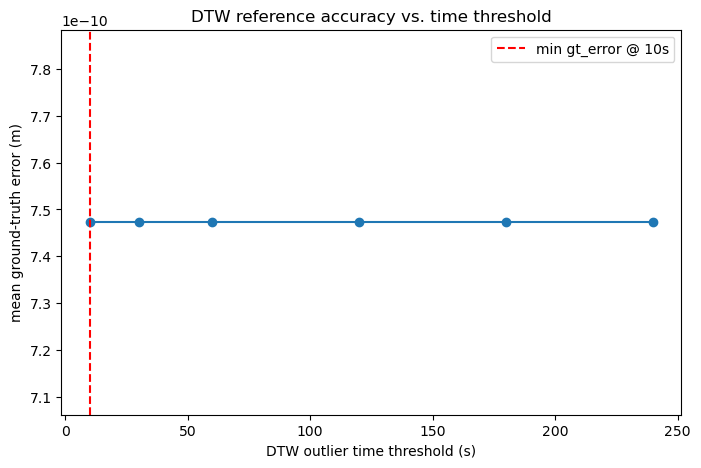

In [11]:
# Plot the mean ground-truth error against the time threshold; the threshold
# that minimizes gt_error is the best candidate.
if "gt_error" in threshold_summary.columns:
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(threshold_summary.index, threshold_summary["gt_error"], marker="o")
    best = threshold_summary["gt_error"].idxmin()
    ax.axvline(best, color="red", linestyle="--", label="min gt_error @ %ss" % best)
    ax.set_xlabel("DTW outlier time threshold (s)")
    ax.set_ylabel("mean ground-truth error (m)")
    ax.set_title("DTW reference accuracy vs. time threshold")
    ax.legend()
    fig

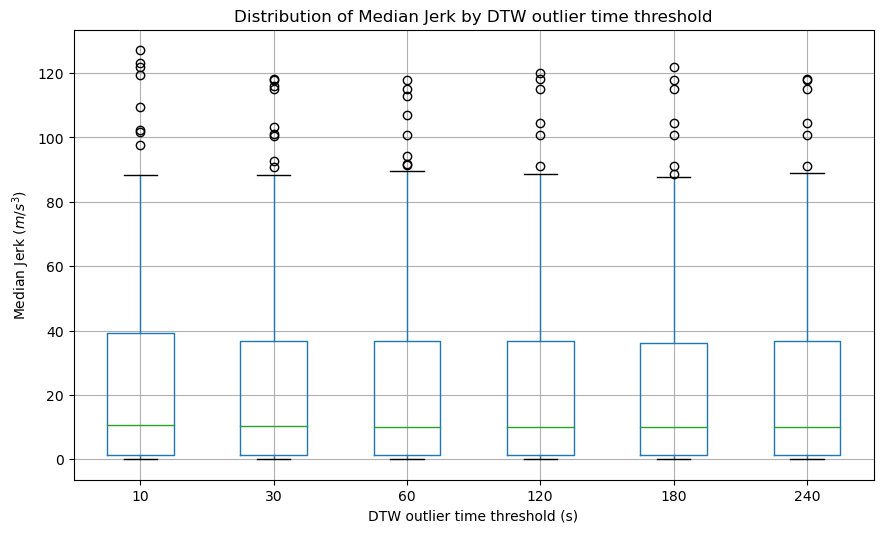

In [12]:
# Plot box plots of median jerk for every time threshold to see how much noise
# remains in the trajectories at different thresholds.
if "median_jerk" in sweep_df.columns:
    fig, ax = plt.subplots(figsize=(10, 6))
    # We drop any NaNs/Infs to ensure the boxplot renders properly
    clean_df = sweep_df[np.isfinite(sweep_df["median_jerk"])]
    clean_df.boxplot(column="median_jerk", by="time_threshold", ax=ax, grid=True)
    ax.set_xlabel("DTW outlier time threshold (s)")
    ax.set_ylabel("Median Jerk ($m/s^3$)")
    ax.set_title("Distribution of Median Jerk by DTW outlier time threshold")
    plt.suptitle("")  # Clear the automatic pandas subtitle
    fig
